In [19]:
import random
import torch
from d2l import (torch as d2l)

#创建数据集
将根据带有噪声的线性模型构造一个人造数据集

In [20]:
def synthetic_data(w, b, num_examples): #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [21]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.5741, -1.4205]) 
label: tensor([7.8614])


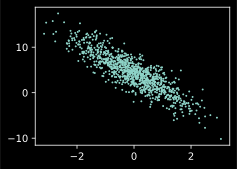

In [22]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

#读取数据集
训练模型时要对数据集进行遍历,每次抽取一小批量样本,并使用它们来更新我们的模型

In [23]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的,没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(  indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [24]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.2403, -0.8807],
        [ 1.3908,  1.1093],
        [-2.0559, -0.6198],
        [-1.0039, -0.2683],
        [-1.5147,  2.2939],
        [-0.1423, -0.5050],
        [-0.4957,  0.9636],
        [-1.3676,  1.6948],
        [ 3.1400,  1.6430],
        [-0.6468, -0.1671]]) 
 tensor([[ 6.7069],
        [ 3.2076],
        [ 2.2233],
        [ 3.1174],
        [-6.6170],
        [ 5.6252],
        [-0.0692],
        [-4.2928],
        [ 4.8815],
        [ 3.4870]])


##初始化模型参数

In [25]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

##定义模型

In [26]:
def linreg(X, w, b): #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

##定义损失函数
需要将真实值y的形状转换为和预测值y_hat的形状相同

In [27]:
def squared_loss(y_hat, y): #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

##定义优化算法

In [28]:
def sgd(params, lr, batch_size): #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

#训练
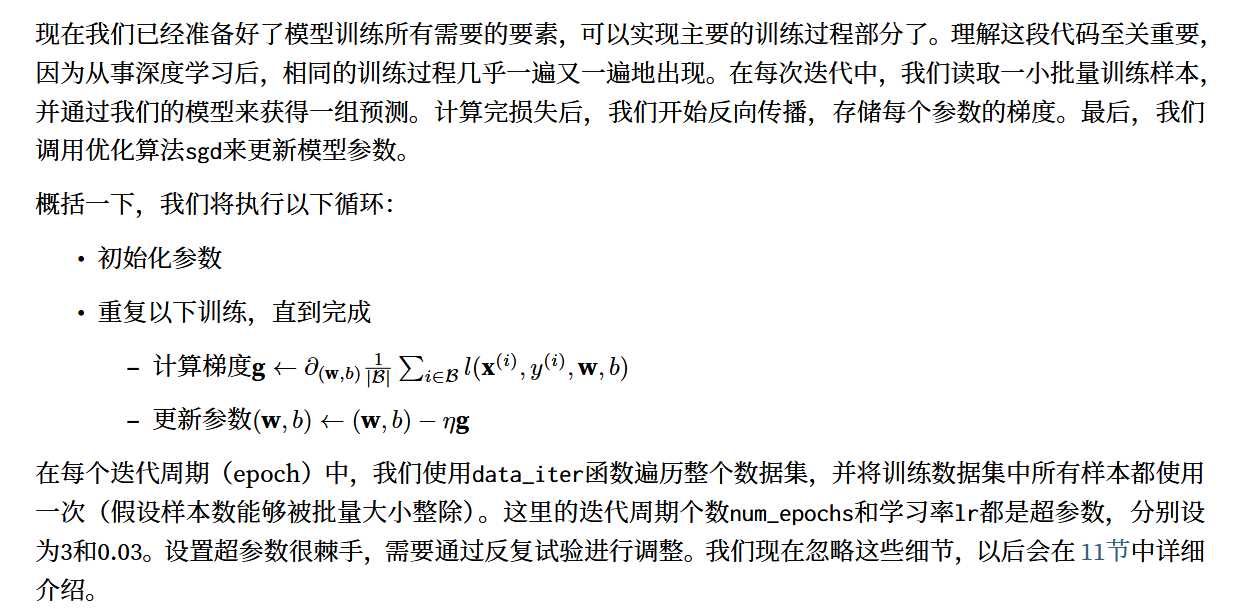

In [29]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):


    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # X和y的小批量损失
        # 因为l形状是(batch_size,1),而不是一个标量。l中的所有元素被加到一起,
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)    # 使用参数的梯度更新参数
    with torch.no_grad():
         train_l = loss(net(features, w, b), labels)
         print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.030366
epoch 2, loss 0.000106
epoch 3, loss 0.000050
